<a href="https://colab.research.google.com/github/tatyanalitvin/python_for_ds_tasks/blob/dev/Unit_03/HW_%D0%90%D0%BB%D0%B3%D0%BE%D1%80%D0%B8%D1%82%D0%BC%D0%B8_%D0%BA%D0%BB%D0%B0%D1%81%D1%82%D0%B5%D1%80%D0%B8%D0%B7%D0%B0%D1%86%D1%96%D1%97.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [66]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans, DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.neighbors import NearestNeighbors

from sklearn import metrics


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
path = '/content/drive/MyDrive/Colab Notebooks/ML for People/Data/marketing_campaign.csv'

### Домашнє завдання: Кластеризація в Аналізі Персоналій Клієнтів

#### Контекст
В цьому ДЗ ми скористаємось алгоритмами кластеризації для задачі аналізу портретів клієнтів (Customer Personality Analysis).

Customer Personality Analysis - це аналіз різних сегментів клієнтів компанії. Цей аналіз дозволяє бізнесу краще розуміти своїх клієнтів і полегшує процес адаптації продуктів під конкретні потреби, поведінку та інтереси різних типів клієнтів.

Аналіз портретів клієнтів допомагає бізнесу змінювати свій продукт на основі цільової аудиторії, розділеної на різні сегменти. Наприклад, замість того, щоб витрачати гроші на маркетинг нового продукту для всіх клієнтів у базі даних компанії, бізнес може проаналізувати, який сегмент клієнтів найімовірніше придбає продукт, і потім зосередити маркетингові зусилля лише на цьому сегменті.

#### Завдання
На основі наданих даних в файлі `marketing_campaign.csv` потрібно виконати кластеризацію, щоб виявити сегменти клієнтів.

#### Вхідні дані
Вам надано набір даних з такими атрибутами:

**Характеристики користувачів:**
- `ID`: Унікальний ідентифікатор клієнта
- `Year_Birth`: Рік народження клієнта
- `Education`: Рівень освіти клієнта
- `Marital_Status`: Сімейний стан клієнта
- `Income`: Річний дохід домогосподарства клієнта
- `Kidhome`: Кількість дітей у домогосподарстві клієнта
- `Teenhome`: Кількість підлітків у домогосподарстві клієнта
- `Dt_Customer`: Дата реєстрації клієнта у компанії
- `Recency`: Кількість днів з моменту останньої покупки клієнта
- `Complain`: 1, якщо клієнт скаржився за останні 2 роки, 0 - якщо ні

**Продукти:**
- `MntWines`: Сума, витрачена на вино за останні 2 роки
- `MntFruits`: Сума, витрачена на фрукти за останні 2 роки
- `MntMeatProducts`: Сума, витрачена на м'ясні продукти за останні 2 роки
- `MntFishProducts`: Сума, витрачена на рибні продукти за останні 2 роки
- `MntSweetProducts`: Сума, витрачена на солодощі за останні 2 роки
- `MntGoldProds`: Сума, витрачена на золото за останні 2 роки

**Акції:**
- `NumDealsPurchases`: Кількість покупок, зроблених з використанням знижок
- `AcceptedCmp1`: 1, якщо клієнт прийняв пропозицію у першій кампанії, 0 - якщо ні
- `AcceptedCmp2`: 1, якщо клієнт прийняв пропозицію у другій кампанії, 0 - якщо ні
- `AcceptedCmp3`: 1, якщо клієнт прийняв пропозицію у третій кампанії, 0 - якщо ні
- `AcceptedCmp4`: 1, якщо клієнт прийняв пропозицію у четвертій кампанії, 0 - якщо ні
- `AcceptedCmp5`: 1, якщо клієнт прийняв пропозицію у п'ятій кампанії, 0 - якщо ні
- `Response`: 1, якщо клієнт прийняв пропозицію в останній кампанії, 0 - якщо ні

**Взаємодія з компанією:**
- `NumWebPurchases`: Кількість покупок, зроблених через вебсайт компанії
- `NumCatalogPurchases`: Кількість покупок, зроблених за каталогом
- `NumStorePurchases`: Кількість покупок, зроблених безпосередньо у магазинах
- `NumWebVisitsMonth`: Кількість відвідувань вебсайту компанії за останній місяць


**Завдання 1**. Завантажте дані з `marketing_campaign.csv` в Pandas dataframe і виведіть основну інформацію про дані: скільки всього рядків і колонок, які типи даних мають колонки, скільки пропущених значень.

In [18]:
df = pd.read_csv(path, sep='\t', index_col='ID')
df



,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
ID,,,,,,,,,,,,,,,,,,,,,
5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,...,7,0,0,0,0,0,0,3,11,1
2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,...,5,0,0,0,0,0,0,3,11,0
4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,...,4,0,0,0,0,0,0,3,11,0
6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,...,6,0,0,0,0,0,0,3,11,0
5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,...,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,43,...,5,0,0,0,0,0,0,3,11,0
4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,0,...,7,0,0,0,1,0,0,3,11,0
7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,48,...,6,0,1,0,0,0,0,3,11,0


In [13]:
print(f'Кількість рядків: {df.shape[0]}')
print(f'Кількість колонок: {df.shape[1]}')

Кількість рядків: 2240
Кількість колонок: 28


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2240 entries, 5524 to 9405
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Year_Birth           2240 non-null   int64  
 1   Education            2240 non-null   object 
 2   Marital_Status       2240 non-null   object 
 3   Income               2216 non-null   float64
 4   Kidhome              2240 non-null   int64  
 5   Teenhome             2240 non-null   int64  
 6   Dt_Customer          2240 non-null   object 
 7   Recency              2240 non-null   int64  
 8   MntWines             2240 non-null   int64  
 9   MntFruits            2240 non-null   int64  
 10  MntMeatProducts      2240 non-null   int64  
 11  MntFishProducts      2240 non-null   int64  
 12  MntSweetProducts     2240 non-null   int64  
 13  MntGoldProds         2240 non-null   int64  
 14  NumDealsPurchases    2240 non-null   int64  
 15  NumWebPurchases      2240 non-null   int

In [12]:
df.describe().round(2)

,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.00,2216.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,...,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.0,2240.0,2240.00
mean,1968.81,52247.25,0.44,0.51,49.11,303.94,26.30,166.95,37.53,27.06,...,5.32,0.07,0.07,0.07,0.06,0.01,0.01,3.0,11.0,0.15
std,11.98,25173.08,0.54,0.54,28.96,336.60,39.77,225.72,54.63,41.28,...,2.43,0.26,0.26,0.26,0.25,0.11,0.10,0.0,0.0,0.36
min,1893.00,1730.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,3.0,11.0,0.00
25%,1959.00,35303.00,0.00,0.00,24.00,23.75,1.00,16.00,3.00,1.00,...,3.00,0.00,0.00,0.00,0.00,0.00,0.00,3.0,11.0,0.00
50%,1970.00,51381.50,0.00,0.00,49.00,173.50,8.00,67.00,12.00,8.00,...,6.00,0.00,0.00,0.00,0.00,0.00,0.00,3.0,11.0,0.00
75%,1977.00,68522.00,1.00,1.00,74.00,504.25,33.00,232.00,50.00,33.00,...,7.00,0.00,0.00,0.00,0.00,0.00,0.00,3.0,11.0,0.00
max,1996.00,666666.00,2.00,2.00,99.00,1493.00,199.00,1725.00,259.00,263.00,...,20.00,1.00,1.00,1.00,1.00,1.00,1.00,3.0,11.0,1.00


In [16]:
missed = df.isnull().sum()[df.isnull().sum() > 0]
print(f"""Пропущені значення:
{missed}
      """)

Пропущені значення:
Income    24
dtype: int64
      


**Завдання 2.** Заповніть пропущені значення з врахуванням того завдання (кластеризація), яке ми виконуємо. Поясніть свій вибір заповнення пропущених значень.

In [19]:
# Для кластеризації заповнюю медіаною,
# оскільки вона стійка до викидів і не спотворює розподіл даних.
df['Income'] = df['Income'].fillna(df['Income'].median())
print(f'Після заповнення: {df["Income"].isnull().sum()}')

Після заповнення: 0


In [20]:
df.isnull().sum().sum()

np.int64(0)

**Завдання 3.** У нас є декілька колонок з категоріальними значеннями та одна колонка з датою. Як би ви обробили ці колонки для того, аби передати їх в алгоритм кластеризації?

Реалізуйте обробку категоріальних колонок і колонки з датою та перетворіть їх на ознаки, корисні для кластеризації з вашого погляду.

In [21]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
categorical_cols

Index(['Education', 'Marital_Status', 'Dt_Customer'], dtype='object')

In [22]:
df['Education'].unique()

array(['Graduation', 'PhD', 'Master', 'Basic', '2n Cycle'], dtype=object)

In [23]:
df['Marital_Status'].unique()

array(['Single', 'Together', 'Married', 'Divorced', 'Widow', 'Alone',
       'Absurd', 'YOLO'], dtype=object)

In [24]:
df['Dt_Customer'].unique()

array(['04-09-2012', '08-03-2014', '21-08-2013', '10-02-2014',
       '19-01-2014', '09-09-2013', '13-11-2012', '08-05-2013',
       '06-06-2013', '13-03-2014', '15-11-2013', '10-10-2012',
       '24-11-2012', '24-12-2012', '31-08-2012', '28-03-2013',
       '03-11-2012', '08-08-2012', '06-01-2013', '23-12-2012',
       '11-01-2014', '18-03-2013', '02-01-2013', '27-05-2013',
       '20-02-2013', '31-05-2013', '22-11-2013', '22-05-2014',
       '11-05-2013', '29-10-2012', '29-08-2013', '31-12-2013',
       '02-09-2013', '11-02-2014', '01-02-2013', '29-04-2013',
       '12-03-2013', '05-11-2013', '02-10-2013', '28-06-2014',
       '09-11-2012', '24-05-2013', '01-01-2014', '08-11-2012',
       '12-05-2014', '11-08-2012', '07-06-2014', '12-06-2013',
       '19-11-2012', '02-04-2013', '28-04-2014', '17-06-2013',
       '03-03-2014', '04-07-2013', '07-09-2012', '18-02-2013',
       '11-06-2013', '06-12-2013', '21-05-2013', '11-05-2014',
       '19-03-2014', '27-09-2013', '08-04-2013', '11-09

In [25]:
# Education має порядок, але LabelEncoder сортує алфавітно
# і в результаті порушує цей порядок (Basic, 2n Cycle, Graduation, Master, PhD).
# -> ordinal-карта:
edu_order = {
    'Basic': 0,
    '2n Cycle': 1,
    'Graduation': 2,
    'Master': 3,
    'PhD': 4
    }
df['Education_ord'] = df['Education'].map(edu_order)

In [26]:
# Marital_Status номінальна ознака без заданого порядку.
# LabelEncoder ввів би додаткову ординальність, яку KMeans трактуватиме як відстань.
# Alone/Absurd/YOLO -> Single, та one-hot
marital_clean = df['Marital_Status'].replace({
    'Alone': 'Single',
    'Absurd': 'Single',
    'YOLO': 'Single'
    })
marital_dummies = pd.get_dummies(marital_clean, prefix='Marital').astype(int)
df = pd.concat([df, marital_dummies], axis=1)

In [27]:
# Dt_Customer -> кількість днів з моменту реєстрації відносно найпізнішої дати
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True)
max_date = df['Dt_Customer'].max()
df['Customer_Days'] = (max_date - df['Dt_Customer']).dt.days

In [29]:
df.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,Z_CostContact,Z_Revenue,Response,Education_ord,Marital_Divorced,Marital_Married,Marital_Single,Marital_Together,Marital_Widow,Customer_Days
ID,,,,,,,,,,,,,,,,,,,,,
5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,...,3,11,1,2,0,0,1,0,0,663
2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,...,3,11,0,2,0,0,1,0,0,113
4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,...,3,11,0,2,0,0,0,1,0,312
6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,...,3,11,0,2,0,0,0,1,0,139
5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,...,3,11,0,4,0,1,0,0,0,161


**Завдання 4**.
1. Запишіть в змінну X ті дані, які будете кластеризувати.
2. Побудуйте кластеризацію з KMeans на 3 кластери.
3. Обчисліть метрику силуету для цієї кластеризації.

In [30]:
# Виключаємо ID, Dt_Customer, оригінальні категоріальні колонки та константні Z_ колонки.
cols_to_drop = ['ID', 'Dt_Customer', 'Education', 'Marital_Status',
                'Z_CostContact', 'Z_Revenue']
X = df.drop(columns=cols_to_drop, errors='ignore')
X.head()

,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,AcceptedCmp2,Complain,Response,Education_ord,Marital_Divorced,Marital_Married,Marital_Single,Marital_Together,Marital_Widow,Customer_Days
ID,,,,,,,,,,,,,,,,,,,,,
5524,1957,58138.0,0,0,58,635,88,546,172,88,...,0,0,1,2,0,0,1,0,0,663
2174,1954,46344.0,1,1,38,11,1,6,2,1,...,0,0,0,2,0,0,1,0,0,113
4141,1965,71613.0,0,0,26,426,49,127,111,21,...,0,0,0,2,0,0,0,1,0,312
6182,1984,26646.0,1,0,26,11,4,20,10,3,...,0,0,0,2,0,0,0,1,0,139
5324,1981,58293.0,1,0,94,173,43,118,46,27,...,0,0,0,4,0,1,0,0,0,161


In [31]:
print(f'Ознаки для кластеризації ({X.shape[1]}):')
list(X.columns)

Ознаки для кластеризації (30):


['Year_Birth',
 'Income',
 'Kidhome',
 'Teenhome',
 'Recency',
 'MntWines',
 'MntFruits',
 'MntMeatProducts',
 'MntFishProducts',
 'MntSweetProducts',
 'MntGoldProds',
 'NumDealsPurchases',
 'NumWebPurchases',
 'NumCatalogPurchases',
 'NumStorePurchases',
 'NumWebVisitsMonth',
 'AcceptedCmp3',
 'AcceptedCmp4',
 'AcceptedCmp5',
 'AcceptedCmp1',
 'AcceptedCmp2',
 'Complain',
 'Response',
 'Education_ord',
 'Marital_Divorced',
 'Marital_Married',
 'Marital_Single',
 'Marital_Together',
 'Marital_Widow',
 'Customer_Days']

In [32]:
kmeans_3 = KMeans(n_clusters=3, random_state=42, n_init='auto')
labels_3 = kmeans_3.fit_predict(X)

array([0, 0, 1, ..., 0, 1, 0], dtype=int32)

In [33]:
s = metrics.silhouette_score(X, labels_3)
print(f'Silhouette Coefficient для 3 кластерів (без масштабування): {s:.4f}')

Silhouette Coefficient для 3 кластерів (без масштабування): 0.5379


**Завдання 5.** Візуалізуйте знайдені кластери разом з наявними даними та проаналізуйте кластери. У нас ознак більше, ніж 2 або 3, тож, тут треба подумати, які саме ознаки варто використати для візуалізації аби вони були інформативними. Рекомендую точно звернути увагу на харакетиристики про дохід користувачів і те, як вони взаємодять з магазинок (кількість покупок і тд).

Для візуалізації зручно може бути використати `plotly.express.scatter_3d` для 3D графіку розсіювання, але тут можна скористатись будь-яким зрозумілим і зручним для вас методом візуалізації. Опишіть свої спостереження, чи кластери мають сенс?

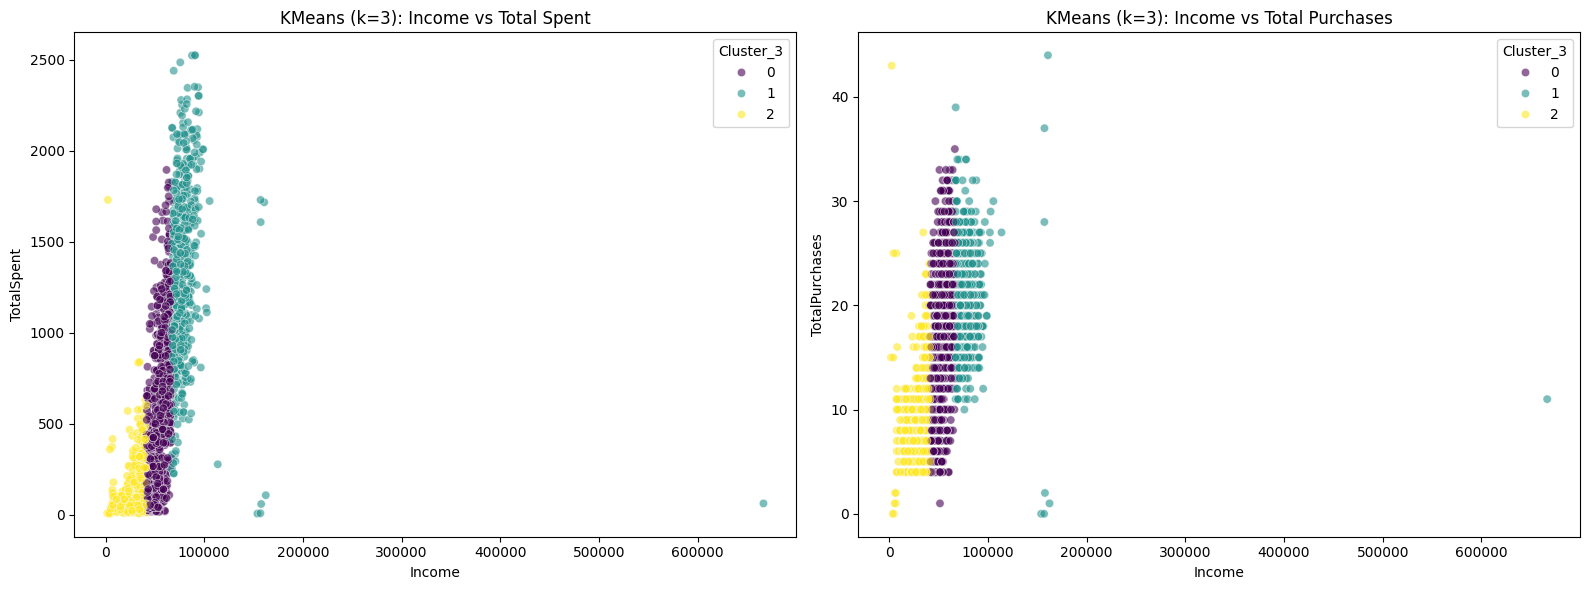

In [34]:
# Візуалізація кластерів через дохід та обсяг покупок.
df['TotalSpent'] = df[[
    'MntWines',
    'MntFruits',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    'MntGoldProds'
    ]].sum(axis=1)
df['TotalPurchases'] = df[[
    'NumWebPurchases',
    'NumCatalogPurchases',
    'NumStorePurchases',
    'NumDealsPurchases'
    ]].sum(axis=1)
df['Cluster_3'] = labels_3

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(
    x='Income', y='TotalSpent',
    hue='Cluster_3',
    palette='viridis',
    data=df,
    alpha=0.6,
    ax=axes[0]
    )
axes[0].set_title('KMeans (k=3): Income vs Total Spent')

sns.scatterplot(
    x='Income', y='TotalPurchases',
    hue='Cluster_3',
    palette='viridis',
    data=df,
    alpha=0.6,
    ax=axes[1]
    )
axes[1].set_title('KMeans (k=3): Income vs Total Purchases')

plt.tight_layout()
plt.show()

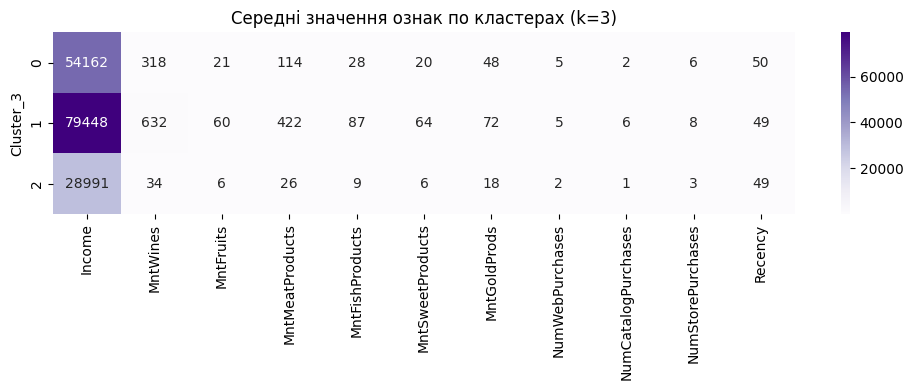

In [35]:
# Інтерпретація кластерів через середні значення (підхід з лекції).
profile_cols = [
    'Income',
    'MntWines',
    'MntFruits',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    'MntGoldProds',
    'NumWebPurchases',
    'NumCatalogPurchases',
    'NumStorePurchases',
    'Recency']

plt.figure(figsize=(10, 4))
sns.heatmap(
    df.groupby('Cluster_3')[profile_cols].mean(),
    cmap='Purples',
    annot=True,
    fmt='.0f'
    )
plt.title('Середні значення ознак по кластерах (k=3)')
plt.tight_layout()
plt.show()

In [36]:
print(f"""Розмір кластерів:
{df['Cluster_3'].value_counts().sort_index()}""")

Розмір кластерів:
Cluster_3
0    852
1    607
2    781
Name: count, dtype: int64



**Спостереження:**

* Кластер 0 (852 клієнти):
Низький дохід, мінімальні витрати на всі категорії товарів, невелика кількість покупок через каталог і магазин.

* Кластер 2 (781 клієнт):
Середній дохід

* Кластер 1 (607 клієнтів):
Найвищий дохід, значні витрати на всі категорії

**Чи мають кластери сенс?** Так, але це простий розподіл за
рівнем доходу/витрат - корисна як baseline ("low / mid / high spender"), але вона не використовує інформацію про канали покупок, лояльність, реакцію на кампанії.


**Завдання 6**. Масштабуйте дані (StandardScaler/MinMaxScaler) і побудуйте знову кластеризацію KMeans на 3 кластери і обчисліть метрику силуету. Опишіть порівняння з експериментом без масштабування значень.

In [37]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[-0.98534473,  0.23569584, -0.82521765, ..., -0.59109863,
        -0.18867619,  1.53118494],
       [-1.23573295, -0.23545419,  1.03255877, ..., -0.59109863,
        -0.18867619, -1.19054458],
       [-0.3176428 ,  0.77399892, -0.82521765, ...,  1.69176504,
        -0.18867619, -0.20577336],
       ...,
       [ 1.01776106,  0.18947568, -0.82521765, ..., -0.59109863,
        -0.18867619, -0.98270342],
       [-1.06880747,  0.67940139, -0.82521765, ...,  1.69176504,
        -0.18867619, -0.97775482],
       [-1.23573295,  0.02520835,  1.03255877, ..., -0.59109863,
        -0.18867619,  1.32829237]])

In [40]:
kmeans_3_scaled = KMeans(n_clusters=3, random_state=42, n_init='auto')
labels_3_scaled = kmeans_3_scaled.fit_predict(X_scaled)
df['Cluster_3_scaled'] = labels_3_scaled

In [41]:
df.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,Marital_Divorced,Marital_Married,Marital_Single,Marital_Together,Marital_Widow,Customer_Days,TotalSpent,TotalPurchases,Cluster_3,Cluster_3_scaled
ID,,,,,,,,,,,,,,,,,,,,,
5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,...,0,0,1,0,0,663,1617,25,0,2
2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,...,0,0,1,0,0,113,27,6,0,0
4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,...,0,0,0,1,0,312,776,21,1,1
6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,...,0,0,0,1,0,139,53,8,2,0
5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,...,0,1,0,0,0,161,422,19,0,0


In [42]:
s_scaled = metrics.silhouette_score(X_scaled, labels_3_scaled)
print(f'Silhouette Coefficient (без масштабування): {s:.4f}')
print(f'Silhouette Coefficient (з масштабуванням):  {s_scaled:.4f}')

Silhouette Coefficient (без масштабування): 0.5379
Silhouette Coefficient (з масштабуванням):  0.1302


* Без масштабування Income та Mnt* колонки домінують через великі абсолютні значення, кластеризація відбувається за ними, а решта ознак майже ігнорується.
* Після StandardScaler усі ознаки мають однаковий внесок у евклідову відстань, тож кластери стають змістовнішими, хоча silhouette на стандартизованих ознаках може бути нижчим, бо точки в просторі стандартних відхилень розташовуються щільніше.

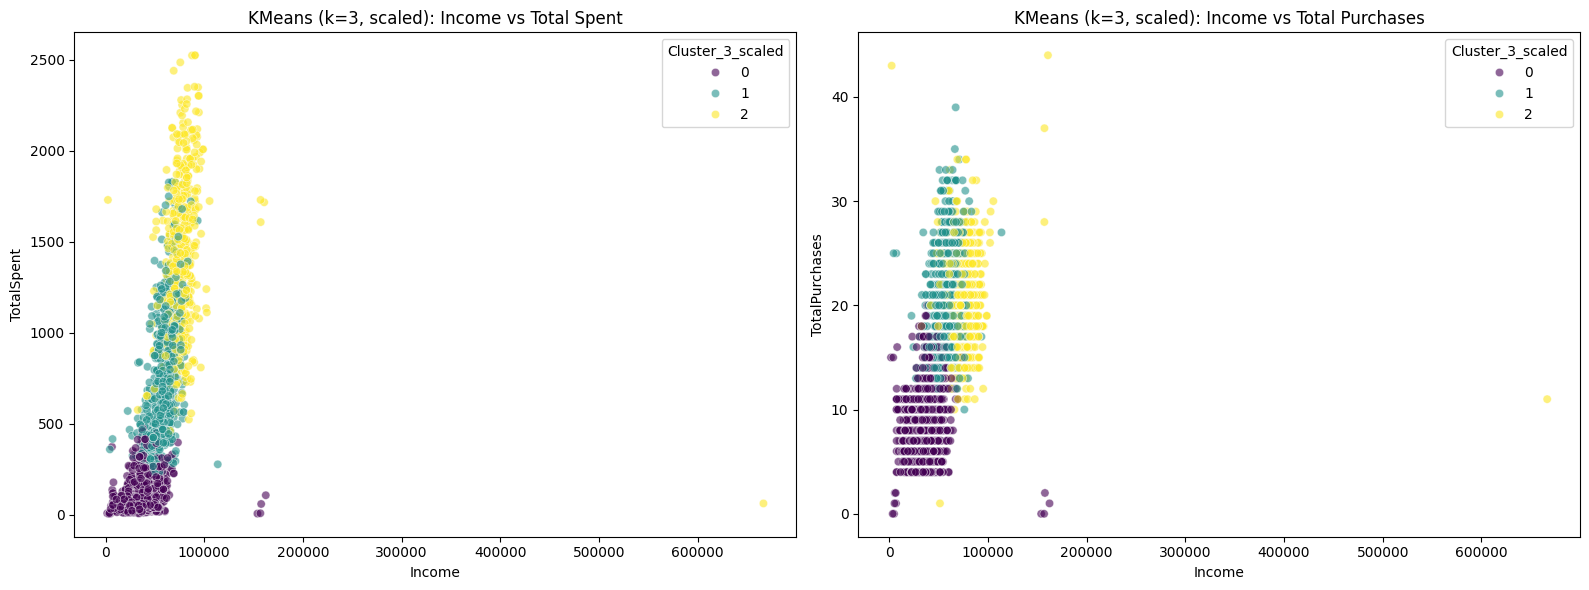

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(
    x='Income', y='TotalSpent',
    hue='Cluster_3_scaled',
    palette='viridis',
    data=df,
    alpha=0.6,
    ax=axes[0]
    )
axes[0].set_title('KMeans (k=3, scaled): Income vs Total Spent')

sns.scatterplot(
    x='Income', y='TotalPurchases',
    hue='Cluster_3_scaled',
    palette='viridis',
    data=df,
    alpha=0.6,
    ax=axes[1]
    )
axes[1].set_title('KMeans (k=3, scaled): Income vs Total Purchases')

plt.tight_layout()
plt.show()

**Завдання 7.** З візуалізацій на попередньому кроці ви могли побачити якісь викиди в даних. Опрацюйте викиди (можна видалити ці рядки або придумати інший спосіб).

In [44]:
print(f'Кількість рядків до видалення викидів: {len(df)}')

Кількість рядків до видалення викидів: 2240


In [46]:
# - Income: одиничні гігантські значення (>600k), що розтягують вісь
# Income — IQR-фільтр
Q1 = df['Income'].quantile(0.25)
Q3 = df['Income'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
income_mask = (df['Income'] >= lower) & (df['Income'] <= upper)

In [47]:
# - Year_Birth: записи 1893/1899/1900 -> нереалістичні роки народження
year_mask = df['Year_Birth'] >= 1940

In [48]:
df_clean = df[income_mask & year_mask].copy()
df_clean.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,Marital_Divorced,Marital_Married,Marital_Single,Marital_Together,Marital_Widow,Customer_Days,TotalSpent,TotalPurchases,Cluster_3,Cluster_3_scaled
ID,,,,,,,,,,,,,,,,,,,,,
5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,...,0,0,1,0,0,663,1617,25,0,2
2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,...,0,0,1,0,0,113,27,6,0,0
4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,...,0,0,0,1,0,312,776,21,1,1
6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,...,0,0,0,1,0,139,53,8,2,0
5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,...,0,1,0,0,0,161,422,19,0,0


In [49]:
print(f'Кількість рядків після видалення викидів: {len(df_clean)}')
print(f'  Income outliers: {(~income_mask).sum()}')
print(f'  Year_Birth outliers: {(~year_mask).sum()}')
print(f'  Усього видалено: {len(df) - len(df_clean)} рядків')

Кількість рядків після видалення викидів: 2229
  Income outliers: 8
  Year_Birth outliers: 3
  Усього видалено: 11 рядків


In [50]:
X_clean = df_clean.drop(
    columns=cols_to_drop + ['TotalSpent', 'TotalPurchases','Cluster_3', 'Cluster_3_scaled'],
    errors='ignore'
    )
X_clean

,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,AcceptedCmp2,Complain,Response,Education_ord,Marital_Divorced,Marital_Married,Marital_Single,Marital_Together,Marital_Widow,Customer_Days
ID,,,,,,,,,,,,,,,,,,,,,
5524,1957,58138.0,0,0,58,635,88,546,172,88,...,0,0,1,2,0,0,1,0,0,663
2174,1954,46344.0,1,1,38,11,1,6,2,1,...,0,0,0,2,0,0,1,0,0,113
4141,1965,71613.0,0,0,26,426,49,127,111,21,...,0,0,0,2,0,0,0,1,0,312
6182,1984,26646.0,1,0,26,11,4,20,10,3,...,0,0,0,2,0,0,0,1,0,139
5324,1981,58293.0,1,0,94,173,43,118,46,27,...,0,0,0,4,0,1,0,0,0,161
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10870,1967,61223.0,0,1,46,709,43,182,42,118,...,0,0,0,2,0,1,0,0,0,381
4001,1946,64014.0,2,1,56,406,0,30,0,0,...,0,0,0,4,0,0,0,1,0,19
7270,1981,56981.0,0,0,91,908,48,217,32,12,...,0,0,0,2,1,0,0,0,0,155


**Завдання 8.** Виконайте Elbow method для пошуку оптимальної кількості кластерів та натренуйте KMeans з тою кількістю кластерів, яку Elbow method показав як оптимальну. Обчисліть метрику силуету. Візуалізуйте кластери. З яким набором даних (масштабованим чи ні) тут працювати - ваш вибір, можна зробити експеримент з обома.

In [51]:
scaler2 = StandardScaler()
X_clean_scaled = scaler2.fit_transform(X_clean)

In [52]:
inertias = []
silhouette_list = []
K_range = list(range(2, 11))

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    km.fit(X_clean_scaled)
    inertias.append(km.inertia_)
    sc = metrics.silhouette_score(X_clean_scaled, km.labels_)
    silhouette_list.append(sc)
    print(f'k={k}: Inertia={km.inertia_:.2f}, Silhouette={sc:.4f}')

k=2: Inertia=54950.98, Silhouette=0.2040
k=3: Inertia=51161.88, Silhouette=0.1345
k=4: Inertia=48683.57, Silhouette=0.1321
k=5: Inertia=47071.83, Silhouette=0.0741
k=6: Inertia=46251.67, Silhouette=0.0750
k=7: Inertia=44916.79, Silhouette=0.0823
k=8: Inertia=42962.70, Silhouette=0.0840
k=9: Inertia=41799.91, Silhouette=0.0924
k=10: Inertia=40013.12, Silhouette=0.1059


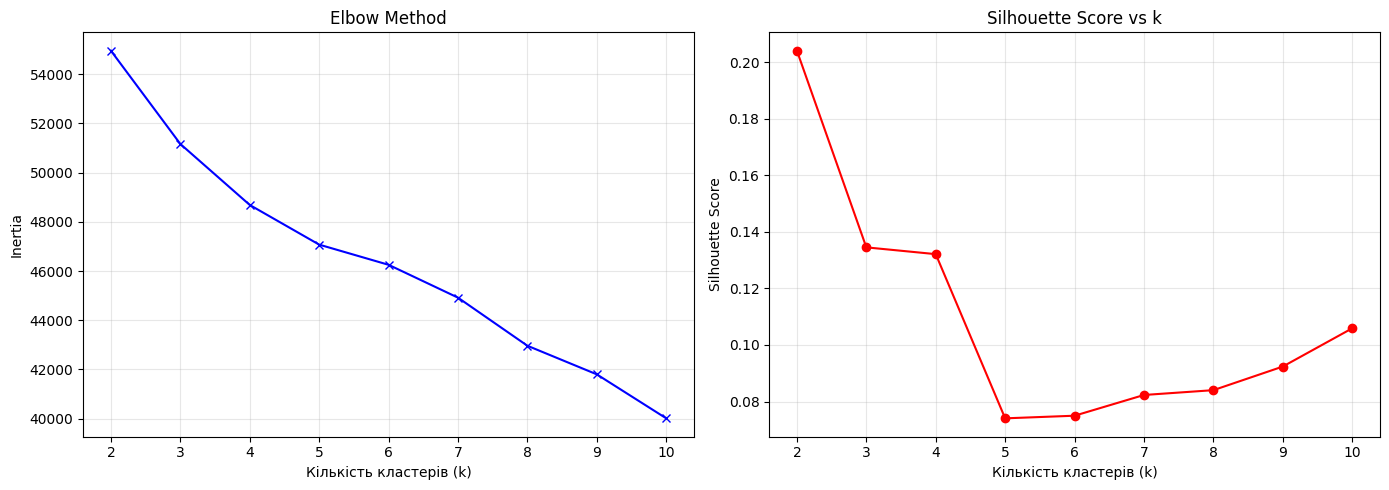

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(K_range, inertias, 'bx-')
axes[0].set_xlabel('Кількість кластерів (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')
axes[0].grid(True, alpha=0.3)
axes[1].plot(K_range, silhouette_list, 'ro-')
axes[1].set_xlabel('Кількість кластерів (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs k')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [57]:
# Elbow method: шукаємо «коліно», де темп зниження inertia різко сповільнюється.
diffs = np.diff(inertias)
second_diffs = np.diff(diffs)
elbow_k = K_range[int(np.argmax(second_diffs)) + 1]
silhouette_k = K_range[int(np.argmax(silhouette_list))]

print(f'\nElbow method: коліно інерції на k={elbow_k}')
print(f'Silhouette: максимум на k={silhouette_k}')


Elbow method: коліно інерції на k=3
Silhouette: максимум на k=2


In [56]:
best_k = elbow_k
print(f'\nОбрано k={best_k} (за Elbow method)')


Обрано k=3 (за Elbow method)


In [58]:
kmeans_opt = KMeans(n_clusters=best_k, random_state=42, n_init='auto')
labels_opt = kmeans_opt.fit_predict(X_clean_scaled)
s_opt = metrics.silhouette_score(X_clean_scaled, labels_opt)
print(f'Silhouette Score з k={best_k}: {s_opt:.4f}')

Silhouette Score з k=3: 0.1345


In [59]:
df_clean['Cluster_opt'] = labels_opt

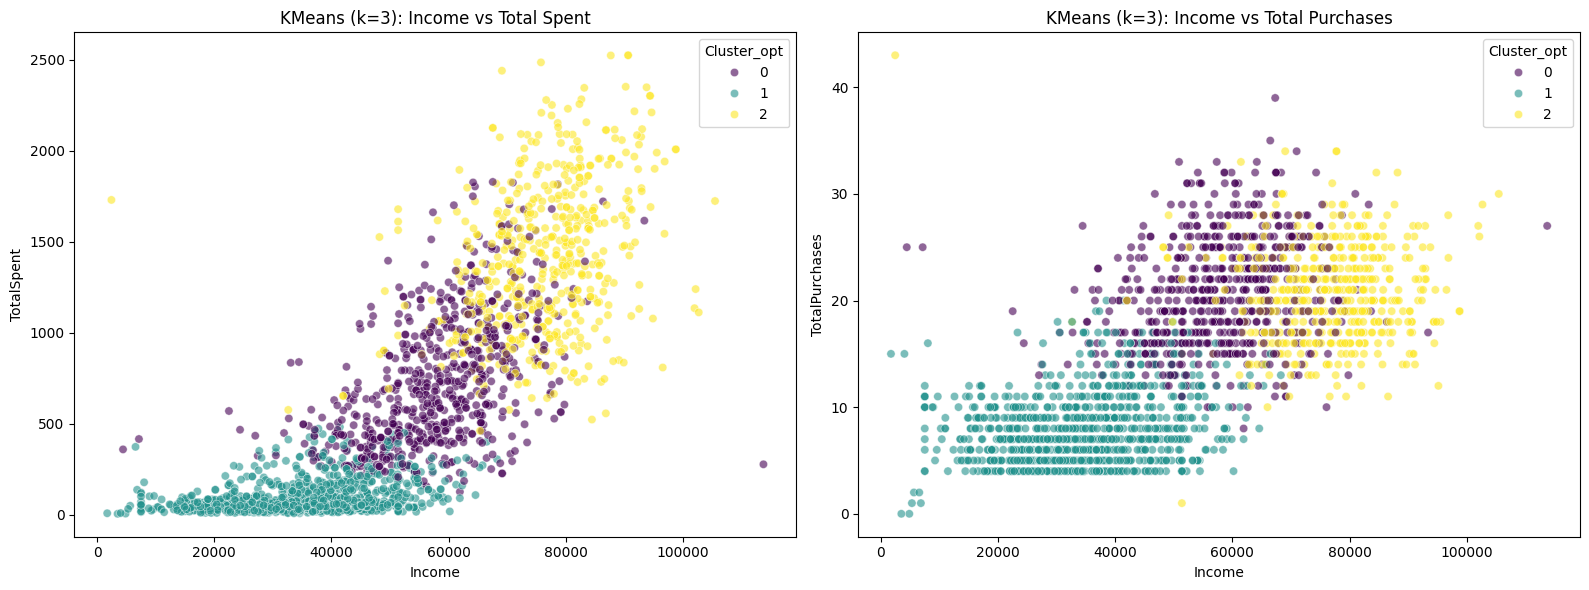

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(
    x='Income', y='TotalSpent',
    hue='Cluster_opt',
    palette='viridis',
    data=df_clean,
    alpha=0.6,
    ax=axes[0]
    )
axes[0].set_title(f'KMeans (k={best_k}): Income vs Total Spent')

sns.scatterplot(
    x='Income', y='TotalPurchases',
    hue='Cluster_opt',
    palette='viridis',
    data=df_clean,
    alpha=0.6,
    ax=axes[1]
    )
axes[1].set_title(f'KMeans (k={best_k}): Income vs Total Purchases')

plt.tight_layout()
plt.show()

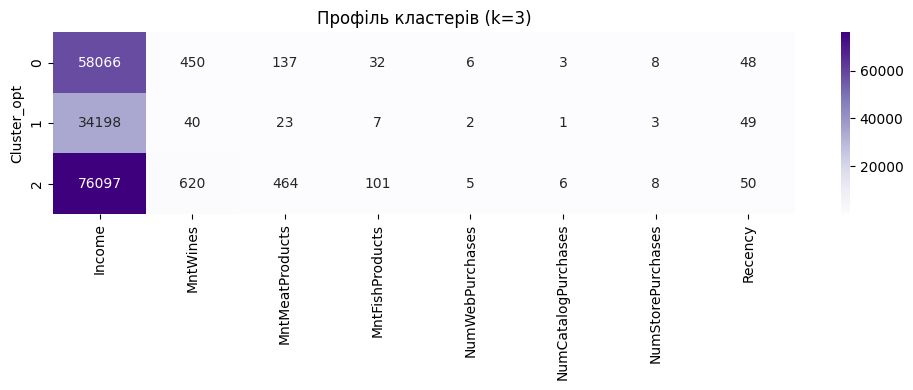

In [61]:
# Інтерпретація: профіль кожного кластера через середні значення.
profile_cols = [
    'Income',
    'MntWines',
    'MntMeatProducts',
    'MntFishProducts',
    'NumWebPurchases',
    'NumCatalogPurchases',
    'NumStorePurchases',
    'Recency'
    ]

plt.figure(figsize=(10, 4))
sns.heatmap(
    df_clean.groupby('Cluster_opt')[profile_cols].mean(),
    cmap='Purples',
    annot=True,
    fmt='.0f'
    )
plt.title(f'Профіль кластерів (k={best_k})')

plt.tight_layout()
plt.show()

**Завдання 9.** Використовуючи методи `scipy` `dendrogram, linkage, fcluster`
1. Побудуйте ієрархічну агломеративну кластеризацію з `single linkage` на даних невідмасштабованих, але з прибраним викидом.
2. Візуалізуйте дендрограму. При візуалізації обовʼязково задайте параметр `truncate_mode='lastp'` - це обріже дендрограму, без цього вона буде завелика, бо у нас тут даних суттєво більше, ніж в лекції.
3. Проаналізуйте дендрограму та побудуйте варіанти плоских кластеризацій з `fcluster` на 2 і 3 кластери. Візуалізуйте результати кожної з цих кластеризацій та зробіть висновок. Чи вважаєте ви якусь з цих кластеризацій вдалою? Що спостерігаєте з цих кластеризацій?
4. Порахуйте мерику силуету для цього методу кластеризації.

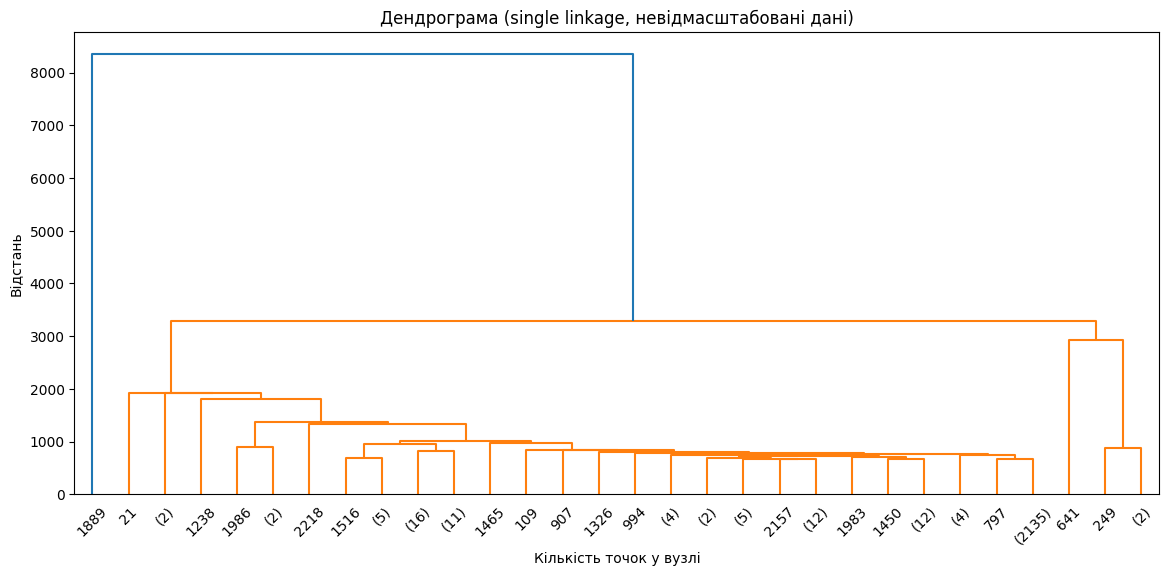

In [62]:
# Single linkage на невідмасштабованих даних без викидів.
Z = linkage(X_clean, method='single')

plt.figure(figsize=(14, 6))
dendrogram(Z, truncate_mode='lastp', p=30)
plt.title('Дендрограма (single linkage, невідмасштабовані дані)')
plt.xlabel('Кількість точок у вузлі')
plt.ylabel('Відстань')
plt.show()

fcluster (2 кластери): Silhouette = 0.5575, розподіл = [2228    1]


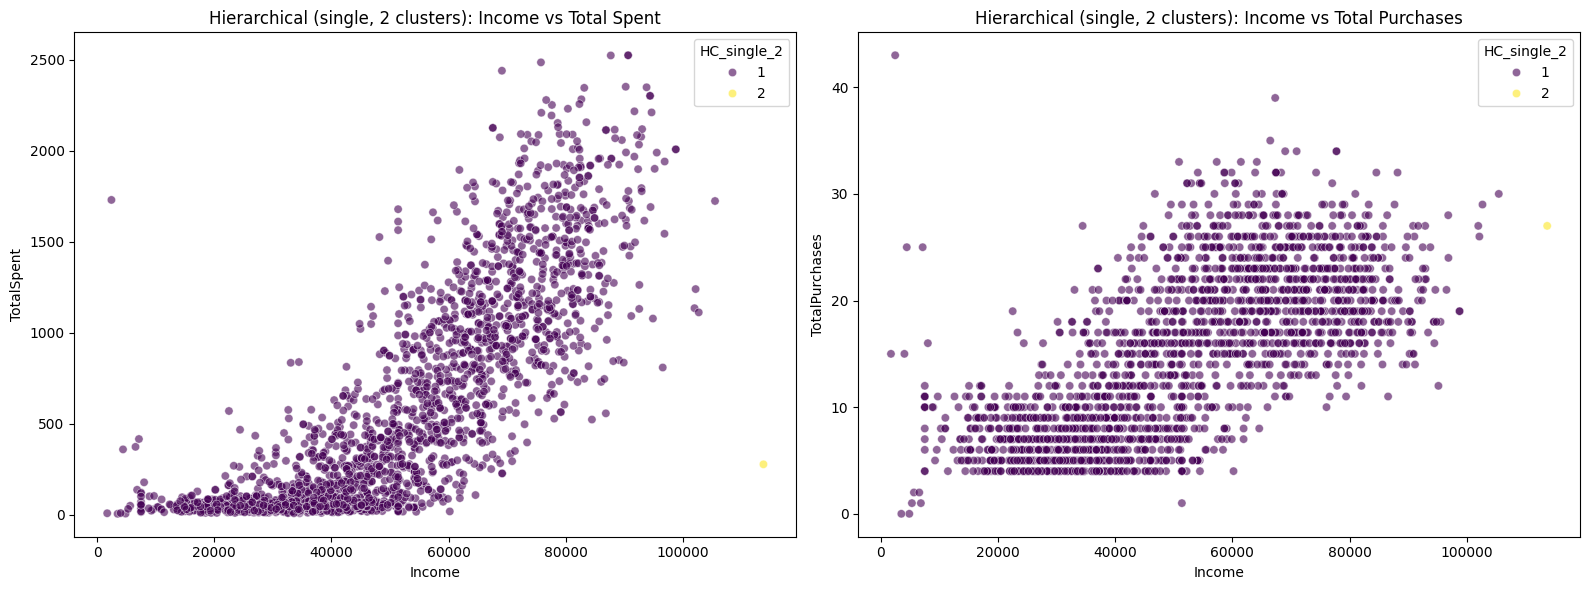

fcluster (3 кластери): Silhouette = 0.4507, розподіл = [2224    4    1]


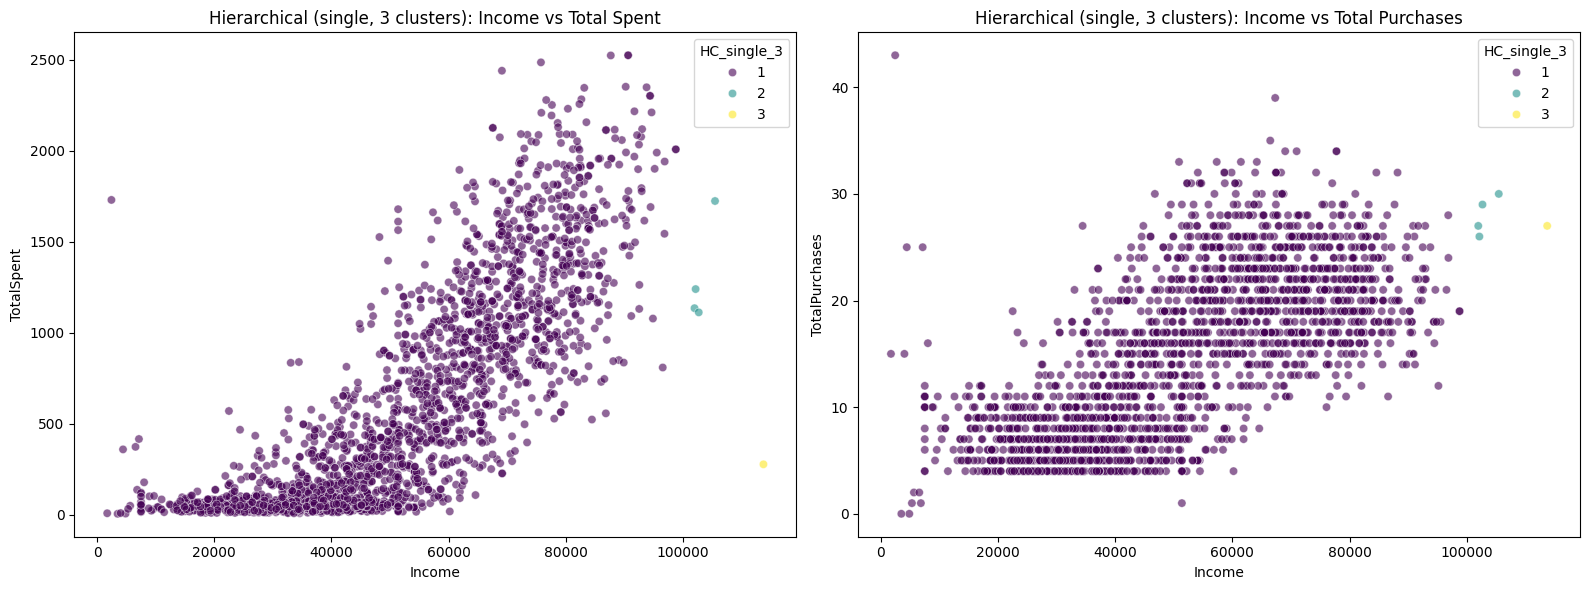

In [63]:
# Плоскі кластеризації на 2 і 3 кластери з fcluster.
for n_clust in [2, 3]:
    flat_labels = fcluster(Z, t=n_clust, criterion='maxclust')
    s_hier = metrics.silhouette_score(X_clean, flat_labels)
    counts = np.unique(flat_labels, return_counts=True)[1]
    print(f'fcluster ({n_clust} кластери): Silhouette = {s_hier:.4f}, розподіл = {counts}')

    df_clean[f'HC_single_{n_clust}'] = flat_labels
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.scatterplot(
        x='Income', y='TotalSpent',
        hue=f'HC_single_{n_clust}',
        palette='viridis',
        data=df_clean,
        alpha=0.6,
        ax=axes[0]
        )
    axes[0].set_title(f'Hierarchical (single, {n_clust} clusters): Income vs Total Spent')

    sns.scatterplot(
        x='Income', y='TotalPurchases',
        hue=f'HC_single_{n_clust}',
        palette='viridis',
        data=df_clean,
        alpha=0.6,
        ax=axes[1]
        )
    axes[1].set_title(f'Hierarchical (single, {n_clust} clusters): Income vs Total Purchases')

    plt.tight_layout()
    plt.show()

**Висновок:**
* один кластер поглинає майже всі точки, а інші містять лише поодинокі екстремальні випадки.
* Високий silhouette тут — артефакт розміру: домінантний кластер компактний у власному центрі, а решта — крихітні. * Така кластеризація не годиться для сегментації клієнтів, але може бути корисною для виявлення викидів.

**Завдання 10.**
1. Використайте метод кластеризації, який ми не використовували в попередніх завданнях цього ДЗ (може бути ієрархічна кластеризація з іншим способом звʼязності або інші методи sklearn).
2. Порахуйте мер=трику силуету і візуалізуйте результат кластеризації. Зробіть висновок про те, чи могла б ця кластеризація бути корисною?

In [67]:
# Підбір eps через k-distance graph (k = min_samples).
# Шукаємо «коліно», де відстань до k-го сусіда різко зростає.
min_samples = 10
nn = NearestNeighbors(n_neighbors=min_samples)
nn.fit(X_clean_scaled)
distances, _ = nn.kneighbors(X_clean_scaled)
k_distances = np.sort(distances[:, -1])

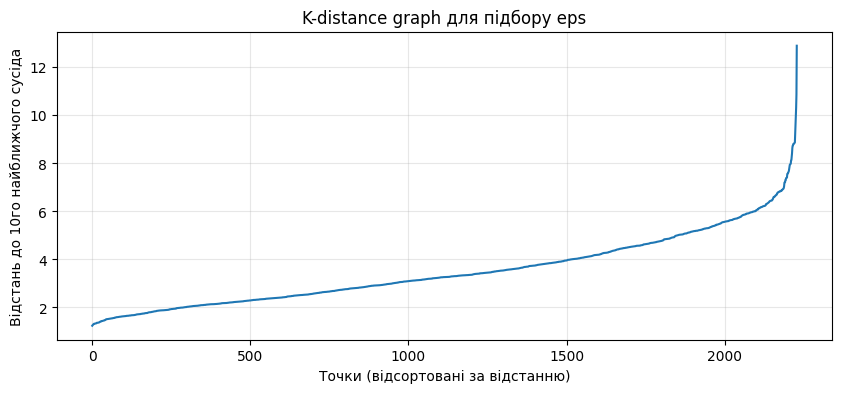

In [68]:
plt.figure(figsize=(10, 4))
plt.plot(k_distances)
plt.xlabel('Точки (відсортовані за відстанню)')
plt.ylabel(f'Відстань до {min_samples}го найближчого сусіда')
plt.title('K-distance graph для підбору eps')
plt.grid(True, alpha=0.3)
plt.show()

In [69]:
# З графіка беремо eps в районі коліна.
eps = 2.5
dbscan = DBSCAN(eps=eps, min_samples=min_samples)
labels_db = dbscan.fit_predict(X_clean_scaled)

n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise = int((labels_db == -1).sum())
print(f'DBSCAN (eps={eps}, min_samples={min_samples}):')
print(f'  Кількість кластерів: {n_clusters_db}')
print(f'  Кількість шумових точок: {n_noise} ({100 * n_noise / len(labels_db):.1f}%)')

DBSCAN (eps=2.5, min_samples=10):
  Кількість кластерів: 4
  Кількість шумових точок: 1332 (59.8%)


In [70]:
if n_clusters_db >= 2:
    mask = labels_db != -1
    s_db = metrics.silhouette_score(X_clean_scaled[mask], labels_db[mask])
    print(f'  Silhouette (без шуму): {s_db:.4f}')
    print(f'  Для порівняння, KMeans (k={best_k}): {s_opt:.4f}')

  Silhouette (без шуму): 0.2351
  Для порівняння, KMeans (k=3): 0.1345


In [71]:
df_clean['Cluster_db'] = labels_db

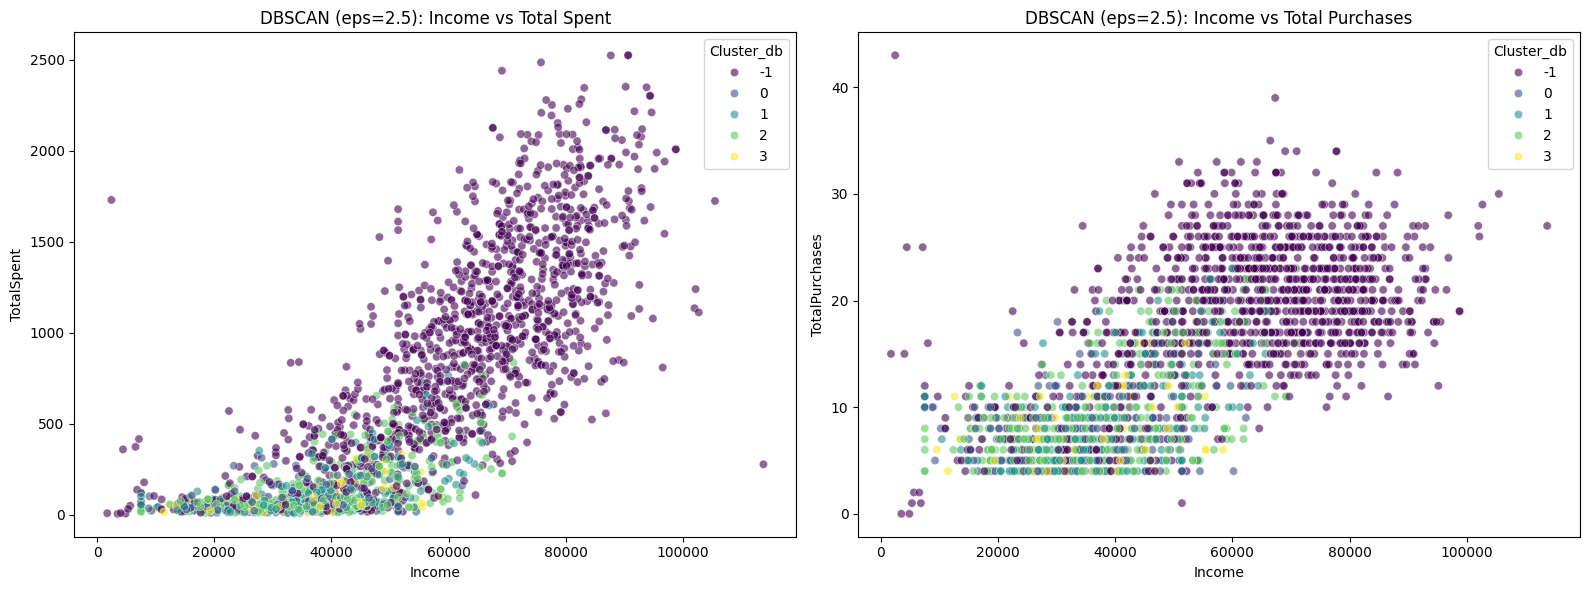

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(
    x='Income', y='TotalSpent',
    hue='Cluster_db',
    palette='viridis',
    data=df_clean,
    alpha=0.6,
    ax=axes[0])
axes[0].set_title(f'DBSCAN (eps={eps}): Income vs Total Spent')
sns.scatterplot(
    x='Income', y='TotalPurchases',
    hue='Cluster_db',
    palette='viridis',
    data=df_clean,
    alpha=0.6,
    ax=axes[1])
axes[1].set_title(f'DBSCAN (eps={eps}): Income vs Total Purchases')

plt.tight_layout()
plt.show()

**Висновок:**
- DBSCAN може бути корисним для сегментації, якщо ми хочемо знайти «щільні ядра» клієнтських груп та одночасно виявити нетипових клієнтів (мітка -1).
- Однак результат сильно залежить від eps та min_samples у випадку, коли щільність клієнтів у просторі ознак неоднорідна, DBSCAN може зливати декілька сегментів в один або, навпаки, помічати багато точок як шум.
- Для класичної маркетингової сегментації KMeans з фіксованим k зазвичай дає більш керований результат, але DBSCAN виявляє нестандартні патерни поведінки клієнтів.